(merging_of_opinions)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# 观点的融合：布莱克韦尔-杜宾斯定理

```{contents} Contents
:depth: 2
```

## 概述

本讲座研究 {cite:t}`blackwell1962` 的观点融合定理。

该定理提出了一个简单的问题：

> 如果两个主体对某个随机过程持有不同的先验信念，但无限期地观察相同的数据流，他们的概率评估最终会收敛吗？

在绝对连续性条件下，答案是肯定的。

如果 $Q \ll P$（即 $P$ 支配 $Q$），那么在 $P$ 和 $Q$ 下关于整个未来路径的条件分布会在全变差意义下融合，$Q$-几乎必然。

如果此外还有 $P \ll Q$（因而 $P \sim Q$），那么同样的结论在两个主体的概率下都成立。

这个结果与其他若干思想相关联：

- 贝叶斯一致性：当先验位于正确的绝对连续性类中时，后验预测趋近于真值（{doc}`likelihood_bayes`）。
- 一致性结果：即使主体从不同的先验出发，共同的数据也能消除分歧（{cite:t}`aumann1976`）。
- 角谷二分法：对于乘积测度，等价性与奇异性可以从一个海林格准则中读出。

我们在离散时间中展开理论，然后勾勒连续时间的类比。

在整个讨论中，我们使用贝塔-伯努利模型作为贯穿始终的例子。

两个主体观察相同的抛硬币结果流，但从关于硬币偏差的不同先验出发。

让我们从一些导入开始。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist
from scipy.special import betaln
import matplotlib as mpl  # i18n
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"  # i18n
mpl.font_manager.fontManager.addfont(FONTPATH)  # i18n
mpl.rcParams['font.family'] = ['Source Han Serif SC']  # i18n

## 序列空间上的概率测度

### 序列空间及其滤流

设 $(S, \mathscr{S})$ 是一个标准博雷尔空间（即与完备可分度量空间的一个博雷尔子集同构的可测空间），称为信号空间。

标准博雷尔假设保证了正则条件分布的存在性，这正是该定理所要求的。

令 $\Omega = S^{\mathbb{N}}$，即所有无限序列
$\omega = (x_1, x_2, \ldots)$（其中 $x_n \in S$）的集合，配备乘积
$\sigma$-代数 $\mathscr{F} = \mathscr{S}^{\otimes \mathbb{N}}$。

对于每个 $n \geq 1$，定义**有限视界** $\sigma$-代数

$$
\mathscr{F}_n = \sigma(x_1, \ldots, x_n),
$$

因此 $\mathscr{F}_1 \subseteq \mathscr{F}_2 \subseteq \cdots \subseteq \mathscr{F}$。

定义**尾 $\sigma$-代数** $\mathscr{F}_\infty = \sigma\!\left(\bigcup_{n \geq 1} \mathscr{F}_n\right)$，它编码了最终能够学到的一切。

集合 $\{\mathscr{F}_n\}_{n \geq 1}$ 是由观察过程生成的**自然滤流**；$\mathscr{F}_n$ 编码了从前 $n$ 个数据点能够学到的一切。

设 $P$ 和 $Q$ 表示 $(\Omega, \mathscr{F})$ 上的两个概率测度。

记 $P_n = P|_{\mathscr{F}_n}$ 和 $Q_n = Q|_{\mathscr{F}_n}$ 表示它们
限制到时刻 $n$ 之前的历史。

### 绝对连续性

```{prf:definition} 绝对连续性
:label: absolute_continuity

$P$ 关于 $Q$ **绝对连续**，记为 $P \ll Q$，如果对于每个 $A \in \mathscr{F}$，
$Q(A) = 0$ 蕴含 $P(A) = 0$。

它们**相互绝对连续**，或**等价**，记为 $P \sim Q$，
如果 $P \ll Q$ 和 $Q \ll P$ 都成立。

$P$ 关于 $Q$ **局部绝对连续**，如果对于每个 $n \geq 1$，$P_n \ll Q_n$。
```

全局绝对连续性 $P \ll Q$ 蕴含局部绝对连续性，但
反之不然。

相互绝对连续意味着两个主体在哪些事件是*可能的*这一点上意见一致。

他们可以对概率有不同看法，但都不会排除对方认为可能的事件。

### 全变差距离

```{prf:definition} 全变差距离
:label: total_variation_distance

对于 $(E, \mathscr{E})$ 上的两个概率测度 $\mu$ 和 $\nu$，

$$
\|\mu - \nu\|_{\mathrm{TV}}
= \sup_{A \in \mathscr{E}} |\mu(A) - \nu(A)|
= \frac{1}{2} \int_E \left|\frac{d\mu}{d\lambda} - \frac{d\nu}{d\lambda}\right| d\lambda,
$$

其中 $\lambda$ 是任意**支配测度**，即 $\mu \ll \lambda$ 且 $\nu \ll \lambda$（例如 $\lambda = \mu + \nu$）。

等价地，$\|\mu - \nu\|_{\mathrm{TV}} \in [0,1]$，其中 0 表示 $\mu = \nu$，1 表示 $\mu \perp \nu$（相互奇异）。
```

当 $\mu \ll \nu$ 且 $f = d\mu/d\nu$ 时，

$$
\|\mu - \nu\|_{\mathrm{TV}} = \mathbb{E}_\nu[(f-1)^+] = 1 - \mathbb{E}_\nu[\min(f,1)].
$$

```{exercise}
:label: tv_derivation

证明上述恒等式。

*提示：*从 $\|\mu - \nu\|_{\mathrm{TV}} = \tfrac{1}{2}\,\mathbb{E}_\nu[|f - 1|]$（这由取 $\nu$ 作为支配测度得出）出发，并利用 $\mathbb{E}_\nu[f] = 1$ 这一事实。
```

```{solution} tv_derivation
:class: dropdown

由于 $\mu \ll \nu$，我们可以取 $\nu$ 作为支配测度，因此 $d\mu/d\nu = f$ 且 $d\nu/d\nu = 1$，给出

$$
\|\mu - \nu\|_{\mathrm{TV}} = \tfrac{1}{2}\,\mathbb{E}_\nu[|f - 1|].
$$

写出 $|f-1| = (f-1)^+ + (1-f)^+$。

由于 $\mu$ 是概率测度，$\mathbb{E}_\nu[f] = 1$，因此两部分贡献相等：$\mathbb{E}_\nu[(f-1)^+] = \mathbb{E}_\nu[(1-f)^+]$。

因此 $\tfrac{1}{2}\,\mathbb{E}_\nu[|f-1|] = \mathbb{E}_\nu[(f-1)^+]$。

接下来，注意 $(f-1)^+ = f - \min(f,1)$，所以 $\mathbb{E}_\nu[(f-1)^+] = \mathbb{E}_\nu[f] - \mathbb{E}_\nu[\min(f,1)] = 1 - \mathbb{E}_\nu[\min(f,1)]$。
```

全变差是概率测度之间距离的最强的标准概念之一。

如果两个测度在全变差意义下接近，那么它们对每个事件的概率都接近。

### 融合问题

布莱克韦尔-杜宾斯定理研究给定*过去*时*未来*的条件分布。

在时刻 $n$，观察到 $(x_1,\ldots,x_n)$ 之后，每个主体对所有未来事件形成一个条件分布：

$$
P(\,\cdot\,|\,\mathscr{F}_n)(\omega), \qquad
Q(\,\cdot\,|\,\mathscr{F}_n)(\omega).
$$

这些是关于整个未来路径的概率测度，而不仅仅是下一个观察。

融合问题询问是否

$$
d_n \;:=\; \bigl\|P(\,\cdot\,|\,\mathscr{F}_n) - Q(\,\cdot\,|\,\mathscr{F}_n)\bigr\|_{\mathrm{TV}}
\;\longrightarrow\; 0
$$

当 $n \to \infty$ 时几乎必然成立。


## 似然比鞅

我们的主要工具是拉东-尼科迪姆导数过程。

### 似然比

由于对于每个 $n$，$Q \ll P$ 蕴含 $Q_n \ll P_n$，拉东-尼科迪姆
定理保证了似然比的存在性

$$
Z_n = \frac{dQ_n}{dP_n}, \qquad Z_n \geq 0 \;\; P\text{-a.s.},
\qquad \mathbb{E}_P[Z_n] = 1.
$$

关键的结构性质是，全局绝对连续性 $Q \ll P$
蕴含在整个 $(\Omega, \mathscr{F})$ 上存在总体拉东-尼科迪姆导数 $Z = dQ/dP$，
并且

$$
Z_n = \mathbb{E}_P[Z \,|\, \mathscr{F}_n] \qquad P\text{-a.s.}
$$

也就是说，$\{Z_n, \mathscr{F}_n\}_{n \geq 1}$ 是一个非负、一致
可积的 $P$-鞅。

```{prf:lemma} 鞅收敛
:label: martingale_convergence

似然比过程 $\{Z_n\}$ 满足：

1. 当 $n \to \infty$ 时，$Z_n \to Z_\infty$ $P$-几乎必然。
2. $Z_\infty = \mathbb{E}_P[Z \,|\, \mathscr{F}_\infty]$ $P$-a.s.
3. $Z_n \to Z_\infty$ 在 $L^1(P)$ 中：$\;\mathbb{E}_P[|Z_n - Z_\infty|] \to 0$。

*证明概要。*非负性和鞅性质给出了在 $L^1(P)$ 中的
有界性。

然后几乎必然收敛由杜布鞅
收敛定理 {cite:t}`doob1953` 得出。

一致可积性（它通过条件延森不等式
由 $Z \in L^1(P)$ 得出）将其提升到
$L^1(P)$ 收敛。$\square$
```

### 将条件测度与似然比联系起来

下面的恒等式将似然比与条件分布联系起来。

在集合 $\{Z_n > 0\}$ 上，$Q(\,\cdot\,|\,\mathscr{F}_n)$ 关于 $P(\,\cdot\,|\,\mathscr{F}_n)$ 的
拉东-尼科迪姆导数为

$$
\frac{d\,Q(\,\cdot\,|\,\mathscr{F}_n)}{d\,P(\,\cdot\,|\,\mathscr{F}_n)}
= \frac{Z_\infty}{Z_n}
\qquad P\text{-a.s. on } \{Z_n > 0\}.
$$

于是应用带 $f = Z_\infty / Z_n$ 的全变差公式给出

$$
d_n
= \mathbb{E}_{P(\cdot|\mathscr{F}_n)}\!\left[\left(\frac{Z_\infty}{Z_n} - 1\right)^{\!+}\right]
= 1 - \mathbb{E}_{P(\cdot|\mathscr{F}_n)}\!\left[\min\!\left(\frac{Z_\infty}{Z_n},\,1\right)\right].
$$

两边乘以 $Z_n$ 并取 $P$-期望（然后对 $\mathscr{F}_n$-可测的 $g$ 使用 $\mathbb{E}_P[Z_n \, g(\mathscr{F}_n)] = \mathbb{E}_Q[g(\mathscr{F}_n)]$）：

$$
2\,\mathbb{E}_Q[d_n] \;=\; \mathbb{E}_P[|Z_\infty - Z_n|],
$$

因此鞅的 $L^1(P)$ 收敛控制了全变差距离趋于零的速度。


## 布莱克韦尔-杜宾斯定理

```{prf:theorem} 布莱克韦尔-杜宾斯（1962）
:label: blackwell_dubins

设 $P$ 和 $Q$ 是 $(\Omega, \mathscr{F})$ 上的概率测度，满足
$Q \ll P$。

定义

$$
d_n = \bigl\|P(\,\cdot\,|\,\mathscr{F}_n) - Q(\,\cdot\,|\,\mathscr{F}_n)\bigr\|_{\mathrm{TV}}.
$$

那么 $d_n \to 0$ $Q$-几乎必然。
```

证明有三个步骤。

步骤 1. 通过 $Z_n$ 表示 $d_n$。

如上所示，$d_n$ 可以用 $Z_\infty / Z_n$ 表示，其中 $Z_n = \mathbb{E}_P[Z \,|\, \mathscr{F}_n]$ 且 $Z = dQ/dP$。

这将问题化归为关于 $P$ 下一个鞅的陈述。

步骤 2. $\{d_n\}$ 是一个非负上鞅。

对更多信息取条件平均地降低了可区分性。

形式上，因为
$P(\,\cdot\,|\,\mathscr{F}_n) = \mathbb{E}[P(\,\cdot\,|\,\mathscr{F}_{n+1})\,|\,\mathscr{F}_n]$
且全变差是凸的，

$$
\mathbb{E}_Q[d_{n+1}\,|\,\mathscr{F}_n] \leq d_n \qquad Q\text{-a.s.}
$$

因此 $\{d_n, \mathscr{F}_n\}$ 是 $[0,1]$ 中的非负 $Q$-上鞅。

由杜布定理，$d_n \to d_\infty$ $Q$-几乎必然，其中 $d_\infty$ 是某个取值于 $[0,1]$ 的随机变量。

步骤 3. 几乎必然的极限为零。

由步骤 1 和 $L^1$ 界：

$$
\mathbb{E}_Q[d_n] = \tfrac{1}{2}\,\mathbb{E}_P[|Z_\infty - Z_n|] \to 0.
$$

右边由鞅的 $L^1(P)$ 收敛而消失。

因此 $d_n \to 0$ 在 $L^1(Q)$ 中，从而在 $Q$-概率意义下成立。

由于 $d_n$ 已经 $Q$-几乎必然收敛，其极限必须满足 $d_\infty = 0$ $Q$-a.s. $\square$

```{prf:remark} 单边绝对连续性 vs. 相互绝对连续性
:label: one_sided_vs_mutual

该定理只要求 $Q \ll P$，而不要求 $P \ll Q$。

单边绝对连续性 $Q \ll P$ 给出 $Q$-几乎必然的融合。

由于 $Q \ll P$ 意味着每个 $P$-零集也是 $Q$-零集，$Q$-a.s. 收敛并不*自动*蕴含 $P$-a.s. 收敛。

要得出在*两个*主体的测度下 $d_n \to 0$，需要相互绝对连续性 $P \sim Q$。

在加上 $P \ll Q$ 之后，可以将 $P$ 和 $Q$ 的角色互换运行该证明，从而也得到 $d_n \to 0$ $P$-a.s.。
```

```{prf:remark} 尖锐性
:label: sharpness

绝对连续性很重要。

当 $P$ 和 $Q$ 奇异时，融合可能完全失败。

下面的点质量例子对每个 $n$ 都有 $d_n = 1$。

对于乘积测度，后面的角谷定理给出了一个尖锐的等价性与奇异性二分法。
```


## 贝塔-伯努利模型

在转向 Python 之前，我们介绍贯穿所有
模拟的主要例子。

### 模型

假设数据流 $(x_1, x_2, \ldots)$ 由独立同分布的伯努利
抽样构成，未知概率为 $p^* \in (0,1)$。

主体 $i$ 有一个贝塔先验：

$$
p \sim \mathrm{Beta}(\alpha_i, \beta_i), \qquad i = 1, 2.
$$

在观察到 $n$ 次抽样中有 $k$ 次成功之后，贝叶斯法则给出
后验

$$
p \,|\, x^n \;\sim\; \mathrm{Beta}(\alpha_i + k,\; \beta_i + n - k),
$$

而单步向前预测概率为

$$
\hat{p}_i^n = \mathbb{E}[p\,|\,x^n] = \frac{\alpha_i + k}{\alpha_i + \beta_i + n}.
$$

由强大数定律，$k/n \to p^*$ 几乎必然，因此无论
主体的初始先验 $(\alpha_i, \beta_i)$ 如何，$\hat{p}_1^n$ 和 $\hat{p}_2^n$ 都收敛到 $p^*$。

### 边缘似然与似然比

对于每个固定的值 $p \in (0,1)$，令 $P_p$ 表示无限序列上的独立同分布伯努利$(p)$
概率律。

主体 $i$ 不知道 $p$。

相反，主体 $i$ 对 $p$ 放置先验密度 $\pi_i$，这通过下式在数据序列上诱导出
一个概率测度 $P_i$

$$
P_i(A) = \int_0^1 P_p(A)\,\pi_i(p)\,dp
\qquad \text{对于每个事件 } A.
$$

因此 $P_i$ 是主体在对 $p$ 的不确定性取平均之后关于
历史的边缘概率测度。

特别地，如果 $x^n$ 是一个精确的观察历史，有 $k$ 次成功，那么
$P_i(x^n)$ 表示主体 $i$ 在这个混合测度下赋予该历史的概率。

要计算它，从贝塔密度出发

$$
\pi_i(p)
= \frac{p^{\alpha_i - 1} (1-p)^{\beta_i - 1}}{B(\alpha_i, \beta_i)},
\qquad 0 < p < 1.
$$

给定 $p$，该有序历史的概率为 $p^k (1-p)^{n-k}$。

因此

$$
\begin{aligned}
P_i(x^n)
&= \int_0^1 p^k (1-p)^{n-k} \pi_i(p)\, dp \\
&= \frac{1}{B(\alpha_i, \beta_i)}
\int_0^1 p^{\alpha_i + k - 1} (1-p)^{\beta_i + n - k - 1}\, dp \\
&= \frac{B(\alpha_i + k,\; \beta_i + n - k)}{B(\alpha_i,\, \beta_i)}.
\end{aligned}
$$

其中 $B(a,b) = \Gamma(a)\Gamma(b)/\Gamma(a+b)$ 是贝塔函数。

这个表达式是有序历史 $x^n$ 的概率。

它仅通过计数 $k$ 依赖于数据，因此成功次数相同的历史获得相同的概率。

因此时刻 $n$ 处的似然比为

$$
Z_n = \frac{P_{1,n}(x^n)}{P_{2,n}(x^n)}
= \frac{B(\alpha_2,\, \beta_2)}{B(\alpha_1,\, \beta_1)}
\cdot
\frac{B(\alpha_1 + k,\, \beta_1 + n - k)}{B(\alpha_2 + k,\, \beta_2 + n - k)}.
$$

这是 $P_2$（主体 2 的概率）下的一个鞅，它几乎必然
收敛到一个有限正极限 $Z_\infty$，反映了对于任何具有正参数的贝塔先验，
$P_1 \sim P_2$ 这一事实。

### 精确的布莱克韦尔-杜宾斯距离

对于贝塔-伯努利模型，存在一个 $d_n$ 的简洁公式。

由德菲内蒂定理，给定过去时每个主体对*未来无限序列*的条件分布
是独立同分布伯努利$(p)$
过程的混合，其中 $p$ 从后验贝塔分布抽取。

由于不同 $p$ 的伯努利$(p)^{\infty}$ 测度相互
奇异（经验频率精确地识别出 $p$），关于未来的两个条件分布之间的全变差距离
等于关于参数 $p$ 的两个后验分布之间的全变差
距离。

全变差距离为

$$
d_n
= \bigl\|\mathrm{Beta}(\alpha_1 + k_n,\,\beta_1 + n - k_n)
- \mathrm{Beta}(\alpha_2 + k_n,\,\beta_2 + n - k_n)\bigr\|_{\mathrm{TV}}.
$$

当 $k_n/n \to p^*$ 且 $n \to \infty$ 时，两个后验贝塔都集中于 $p^*$ 附近，方差为 $1/n$ 阶，因此 $d_n \to 0$。

下面的代码实现了上述贝塔-伯努利更新、预测概率、全变差距离和似然比的计算。

In [2]:
def beta_bernoulli_update(data, a0, b0):
    """
    序贯贝塔-伯努利贝叶斯更新。
    """
    n = len(data)
    cum_k = np.concatenate([[0], np.cumsum(data)])   # 累积成功次数
    ns    = np.arange(n + 1)                          # 0, 1, ..., n
    a_post = a0 + cum_k
    b_post = b0 + (ns - cum_k)
    return a_post, b_post


def predictive_prob(a_post, b_post):
    """单步向前预测概率 P(X=1 | data)。"""
    return a_post / (a_post + b_post)


def tv_distance_beta(a1, b1, a2, b2, n_grid=2000):
    """
    通过网格求积计算 Beta(a1,b1) 和 Beta(a2,b2) 之间的全变差距离。
    在 (0,1) 上使用精细网格。
    """
    x  = np.linspace(1e-8, 1 - 1e-8, n_grid)
    dx = x[1] - x[0]
    p1 = beta_dist.pdf(x, a1, b1)
    p2 = beta_dist.pdf(x, a2, b2)
    return 0.5 * np.sum(np.abs(p1 - p2)) * dx


def log_likelihood_ratio(data, a1, b1, a2, b2):
    """
    计算对数似然比 log Z_n = log P1_n(data) - log P2_n(data)
    对 `data` 的每个前缀。

    返回一个长度为 len(data) + 1 的数组，从 0 开始（数据之前）。
    """
    a1p, b1p = beta_bernoulli_update(data, a1, b1)
    a2p, b2p = beta_bernoulli_update(data, a2, b2)
    log_P1 = betaln(a1p, b1p) - betaln(a1, b1)
    log_P2 = betaln(a2p, b2p) - betaln(a2, b2)
    return log_P1 - log_P2


def run_simulation(p_true, a1, b1, a2, b2, n_steps, seed=0):
    """
    模拟融合实验的一次实现。

    返回一个字典，包含长度为 n_steps + 1 的数组（索引 0 = 先验）。
    """
    rng  = np.random.default_rng(seed)
    data = rng.binomial(1, p_true, n_steps)

    a1p, b1p = beta_bernoulli_update(data, a1, b1)
    a2p, b2p = beta_bernoulli_update(data, a2, b2)

    pred1    = predictive_prob(a1p, b1p)
    pred2    = predictive_prob(a2p, b2p)
    tv_1step = np.abs(pred1 - pred2)

    # 后验贝塔之间的全变差；在此模型中它等于 d_n
    tv_beta = np.array([
        tv_distance_beta(a1p[i], b1p[i], a2p[i], b2p[i])
        for i in range(n_steps + 1)
    ])

    log_Z = log_likelihood_ratio(data, a1, b1, a2, b2)

    return dict(data=data, pred1=pred1, pred2=pred2,
                tv_1step=tv_1step, tv_beta=tv_beta, log_Z=log_Z)

### 模拟

我们选择两个对一枚硬币偏差持有非常不同信念的主体，这枚硬币正面朝上的真实概率为 $p^* = 0.65$。

- 主体 1（怀疑者）：先验 $\mathrm{Beta}(1, 8)$，因此
  $\hat{p}_1^0 = 1/9 \approx 0.11$。
- 主体 2（乐观者）：先验 $\mathrm{Beta}(8, 1)$，因此
  $\hat{p}_2^0 = 8/9 \approx 0.89$。

两个先验都支撑在整个 $(0,1)$ 上，因此 $P_1 \sim P_2$。

布莱克韦尔-杜宾斯保证融合。

下图展示了这种融合的样子。

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


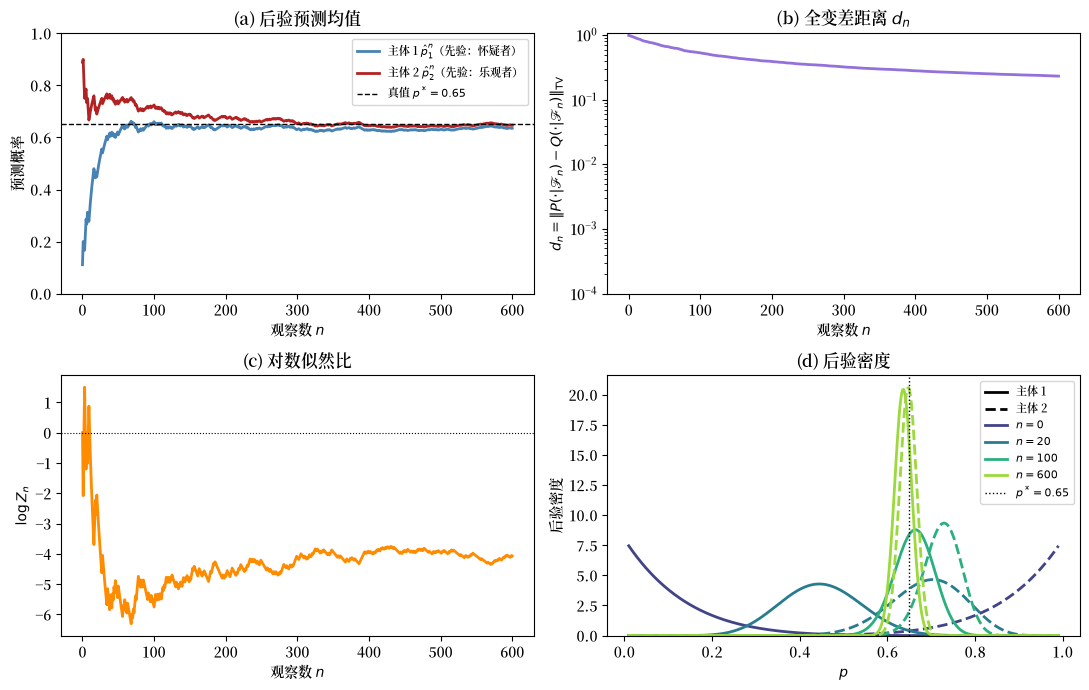

In [3]:
p_true = 0.65
a1, b1 = 1.0, 8.0    # 怀疑者
a2, b2 = 8.0, 1.0    # 乐观者
n_steps = 600

sim = run_simulation(p_true, a1, b1, a2, b2, n_steps, seed=7)
steps = np.arange(n_steps + 1)

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
ax = axes[0, 0]
ax.plot(steps, sim['pred1'], color='steelblue', lw=2,
        label=r'主体 1 $\hat p_1^n$（先验：怀疑者）')
ax.plot(steps, sim['pred2'], color='firebrick', lw=2,
        label=r'主体 2 $\hat p_2^n$（先验：乐观者）')
ax.axhline(p_true, color='black', lw=1.0, ls='--',
           label=f'真值 $p^*={p_true}$')
ax.set_xlabel('观察数 $n$')
ax.set_ylabel('预测概率')
ax.set_title('(a) 后验预测均值')
ax.legend(fontsize=8)
ax.set_ylim(0, 1)

ax = axes[0, 1]
ax.semilogy(steps, sim['tv_beta'] + 1e-10, color='mediumpurple', lw=2)
ax.set_xlabel('观察数 $n$')
ax.set_ylabel(
    r'$d_n = \|P(\cdot|\mathscr{F}_n)'
    r' - Q(\cdot|\mathscr{F}_n)\|_{\mathrm{TV}}$'
)
ax.set_title(r'(b) 全变差距离 $d_n$')
ax.set_ylim(bottom=1e-4)

ax = axes[1, 0]
ax.plot(steps, sim['log_Z'], color='darkorange', lw=2)
ax.axhline(0, color='black', lw=0.8, ls=':')
ax.set_xlabel('观察数 $n$')
ax.set_ylabel(r'$\log Z_n$')
ax.set_title(r'(c) 对数似然比')

ax = axes[1, 1]
xs = np.linspace(0.01, 0.99, 500)
epochs = [0, 20, 100, n_steps]
colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(epochs)))

for epoch, col in zip(epochs, colors):
    k_e = int(np.sum(sim['data'][:epoch]))
    pdf1 = beta_dist.pdf(xs, a1 + k_e, b1 + epoch - k_e)
    pdf2 = beta_dist.pdf(xs, a2 + k_e, b2 + epoch - k_e)
    ax.plot(xs, pdf1, color=col, lw=2, ls='-')
    ax.plot(xs, pdf2, color=col, lw=2, ls='--')

ax.axvline(p_true, color='black', lw=1.0, ls=':', label=f'$p^*={p_true}$')
ax.set_xlabel('$p$')
ax.set_ylabel('后验密度')
ax.set_title('(d) 后验密度')

from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], color='black', lw=2, label='主体 1'),
    Line2D([0], [0], color='black', lw=2, ls='--', label='主体 2'),
]
for epoch, col in zip(epochs, colors):
    handles.append(Line2D([0], [0], color=col, lw=2, label=f'$n={epoch}$'))
handles.append(
    Line2D([0], [0], color='black', lw=1.0, ls=':', label=f'$p^*={p_true}$')
)
ax.legend(handles=handles, fontsize=8)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

四个面板显示：

- 面板 (a)：从 $\hat{p}_1^0 \approx 0.11$ 和
  $\hat{p}_2^0 \approx 0.89$ 出发，两个主体的预测概率都
  收敛到 $p^* = 0.65$。
- 面板 (b)：全变差距离 $d_n$ 在
  对数刻度上衰减到零，与定理一致。
- 面板 (c)：对数似然比 $\log Z_n$ 收敛到一个有限
  值，这与本例中的相互绝对连续性一致。
- 面板 (d)：两个主体的后验贝塔密度起初相距
  甚远（一个接近 0，一个接近 1），并逐渐集中到以真值为中心的相同
  分布。


### 跨多条路径的几乎必然收敛

为了说明该定理的几乎必然特性，我们运行许多独立重复。

该定理关注参考测度下的几乎每条路径，而不仅仅是跨路径的平均。

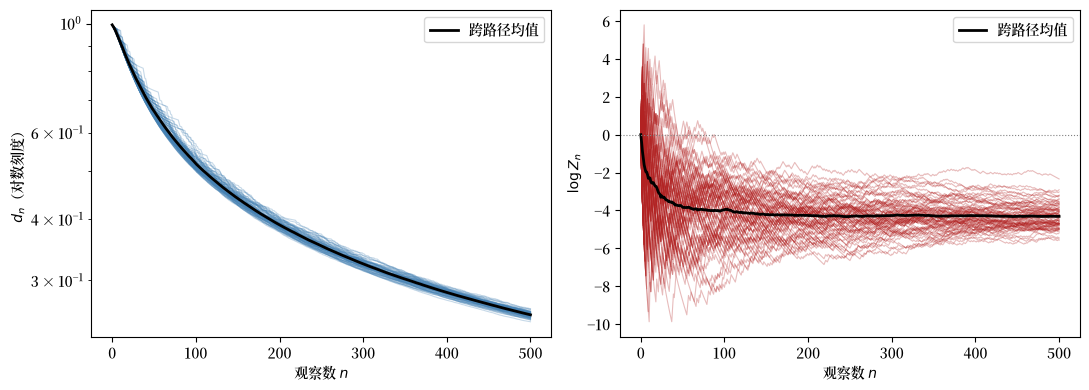

n = 500 时 d_n < 0.30 的路径比例: 1.00
n = 500 时的平均距离: 0.255


In [4]:
N_paths = 80
n_steps = 500

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax_tv  = axes[0]
ax_log = axes[1]

tv_all   = np.empty((N_paths, n_steps + 1))
logZ_all = np.empty((N_paths, n_steps + 1))
steps    = np.arange(n_steps + 1)

for i in range(N_paths):
    s = run_simulation(p_true, a1, b1, a2, b2, n_steps, seed=i)
    tv_all[i]   = s['tv_beta']
    logZ_all[i] = s['log_Z']

for i in range(N_paths):
    ax_tv.semilogy(steps, tv_all[i] + 1e-10, color='steelblue',
                   lw=0.8, alpha=0.3)
ax_tv.semilogy(steps, tv_all.mean(axis=0) + 1e-10,
               color='black', lw=2, label='跨路径均值')
ax_tv.set_xlabel('观察数 $n$')
ax_tv.set_ylabel(r'$d_n$（对数刻度）')
ax_tv.legend()

for i in range(N_paths):
    ax_log.plot(steps, logZ_all[i], color='firebrick',
                lw=0.8, alpha=0.3)
ax_log.plot(steps, logZ_all.mean(axis=0),
            color='black', lw=2, label='跨路径均值')
ax_log.axhline(0, color='gray', lw=0.8, ls=':')
ax_log.set_xlabel('观察数 $n$')
ax_log.set_ylabel(r'$\log Z_n$')
ax_log.legend()

plt.tight_layout()
plt.show()

# 有限视界摘要
frac_below = np.mean(tv_all[:, -1] < 0.30)
mean_final = tv_all[:, -1].mean()
print(f"n = {n_steps} 时 d_n < 0.30 的路径比例: {frac_below:.2f}")
print(f"n = {n_steps} 时的平均距离: {mean_final:.3f}")

在这个有限视界处，距离已从初始水平大幅下降，但尚未接近零。

这仍然与定理一致，因为几乎必然收敛是一个渐近陈述。


### $d_n$ 的上鞅性质

证明依赖于 $\{d_n\}$ 是一个非负上鞅。

我们可以通过观察跨多条路径的平均增量来数值地说明这一点。

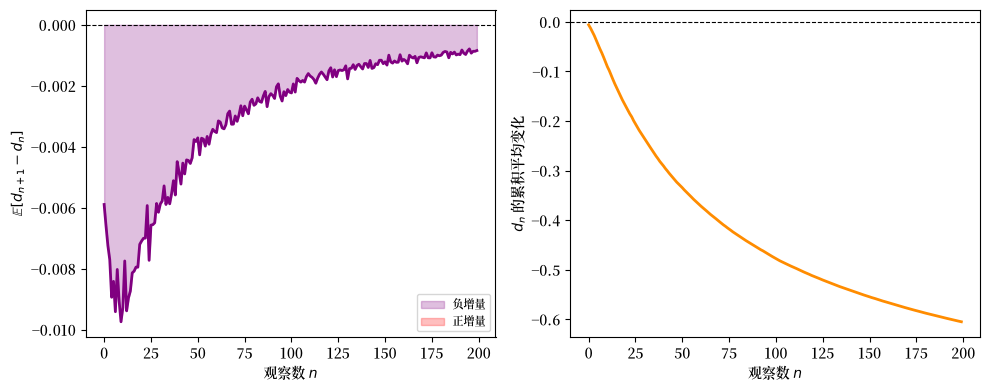

平均减量的步骤比例: 100.00%


In [5]:
diffs = np.diff(tv_all, axis=1)          # 形状 (N_paths, n_steps)
mean_diffs = diffs.mean(axis=0)          # 每步的平均增量
cum_sum   = np.cumsum(mean_diffs)        # 累积平均变化

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
ax.plot(mean_diffs[:200], color='purple', lw=2)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.fill_between(range(200), mean_diffs[:200], 0,
                where=(mean_diffs[:200] < 0), alpha=0.25,
                color='purple', label='负增量')
ax.fill_between(range(200), mean_diffs[:200], 0,
                where=(mean_diffs[:200] > 0), alpha=0.25,
                color='red', label='正增量')
ax.set_xlabel('观察数 $n$')
ax.set_ylabel(r'$\mathbb{E}[d_{n+1} - d_n]$')
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(cum_sum[:200], color='darkorange', lw=2)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('观察数 $n$')
ax.set_ylabel(r'$d_n$ 的累积平均变化')

plt.tight_layout()
plt.show()

frac_decrease = np.mean(mean_diffs < 0)
print(f"平均减量的步骤比例: {frac_decrease:.2%}")

平均增量在大多数步骤为负，累积漂移向下。

这只是一个说明，而不是证明，因为它使用的是无条件平均，而不是定理中完整的条件期望。


## 融合的失败：相互奇异

当假设 $Q \ll P$ 失败时会发生什么？

奇异情形是最简洁的反例。

### 点质量先验

假设两个主体都持有退化（点质量）先验：

- 主体 P：确信 $p = p_P = 0.30$。
- 主体 Q：确信 $p = p_Q = 0.75$。

由于 $P$ 仅对经验频率收敛到 $0.30$ 的序列赋值，而 $Q$ 仅对经验频率收敛到 $0.75$ 的序列赋值，这两个测度相互奇异：$P \perp Q$。

条件分布不更新，因为两个主体都已经确信各自的模型。

对于定理的对象，即整个未来路径的条件律，

$$
\|P(\,\cdot\,|\,\mathscr{F}_n) - Q(\,\cdot\,|\,\mathscr{F}_n)\|_{\mathrm{TV}}
= \|P - Q\|_{\mathrm{TV}} = 1
\quad \text{对所有 } n.
$$

这个等式成立是因为具有不同成功概率的无限乘积伯努利测度是奇异的。

如果我们只向前看一步，预测距离为 $|p_P - p_Q| = 0.45$。

这小于一，但它不是出现在布莱克韦尔-杜宾斯中的量。

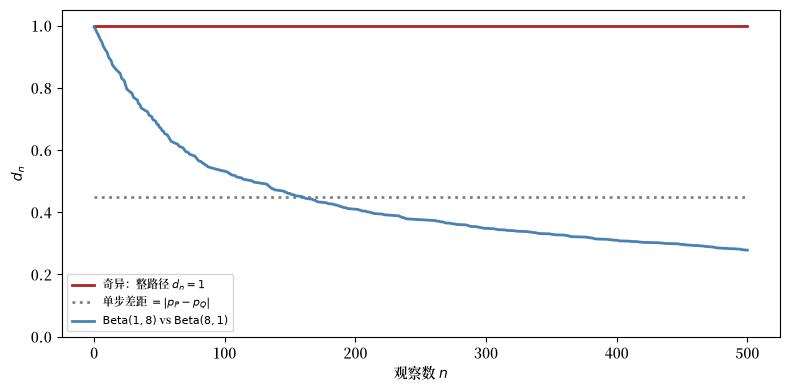

In [6]:
p_P = 0.30
p_Q = 0.75
n_steps = 500

tv_singular_full = np.ones(n_steps + 1)
tv_singular_1step = np.full(n_steps + 1, np.abs(p_P - p_Q))

sim_abs_cont = run_simulation(
    p_Q, 1.0, 8.0, 8.0, 1.0, n_steps, seed=1
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(n_steps + 1), tv_singular_full,
        color='firebrick', lw=2,
        label=r'奇异：整路径 $d_n = 1$')
ax.plot(np.arange(n_steps + 1), tv_singular_1step,
        color='gray', lw=2, ls=':',
        label=r'单步差距 $= |p_P - p_Q|$')
ax.plot(np.arange(n_steps + 1),
        sim_abs_cont['tv_beta'],
        color='steelblue', lw=2,
        label=(r'$\mathrm{Beta}(1,8)$ vs'
               r' $\mathrm{Beta}(8,1)$'))
ax.set_xlabel('观察数 $n$')
ax.set_ylabel(r'$d_n$')
ax.legend(fontsize=8)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

对比是鲜明的。

对于相互绝对连续的先验，$d_n$ 衰减到零。

对于奇异的点质量先验，整个未来路径距离永远保持在一。

更多的数据无法调和这两个主体，因为每个主体都排除了对方赋予正概率的路径。


## 角谷定理：融合何时成立？

一个自然的问题是：对于哪些乘积测度，布莱克韦尔-杜宾斯
假设 $Q \ll P$ 成立？

对于无限乘积测度，答案由
{cite:t}`kakutani1948` 的经典结果给出。

### 海林格亲和度

```{prf:definition} 海林格亲和度
:label: hellinger_affinity

对于 $(S, \mathscr{S})$ 上具有共同
支配测度 $\lambda$ 的概率测度 $P_n$ 和 $Q_n$，**海林格亲和度**为

$$
\rho_n = \int_S \sqrt{\frac{dP_n}{d\lambda} \cdot \frac{dQ_n}{d\lambda}}\,d\lambda
\;\in\; [0, 1].
$$

$\rho_n = 1$ 当且仅当 $P_n = Q_n$；$\rho_n = 0$ 当且仅当 $P_n \perp Q_n$。
```

对于两个特定的一维族：

- 高斯：$P_n = \mathcal{N}(\mu_n, 1)$ vs $Q_n = \mathcal{N}(0,1)$：

$$
\rho_n^{\text{Gauss}} = \exp\!\left(-\frac{\mu_n^2}{8}\right).
$$

- 伯努利：$P_n = \mathrm{Bernoulli}(p)$ vs $Q_n = \mathrm{Bernoulli}(q)$：

$$
\rho_n^{\text{Bern}} = \sqrt{pq} + \sqrt{(1-p)(1-q)}.
$$

### 角谷二分法

```{prf:theorem} 角谷（1948）
:label: kakutani_dichotomy

设 $P = \bigotimes_{n=1}^\infty P_n$ 和 $Q = \bigotimes_{n=1}^\infty Q_n$
是无限乘积测度，其因子逐对等价：对于每个 $n$，$P_n \sim Q_n$。

那么要么 $P \sim Q$，要么 $P \perp Q$；不存在
中间情形。

具体地，

$$
P \sim Q
\quad \iff \quad
\prod_{n=1}^\infty \rho_n > 0
\quad \iff \quad
\sum_{n=1}^\infty (1 - \rho_n) < \infty.
$$

如果 $\prod_{n=1}^\infty \rho_n = 0$，那么 $P \perp Q$。

*证明思路。*
一个标准证明研究似然比鞅
$Z_N = \prod_{n=1}^N (dP_n/dQ_n)$ 连同恒等式
$\mathbb{E}_Q[\sqrt{Z_N}] = \prod_{n=1}^N \rho_n$。

乘积保持正对应于等价性，而乘积坍缩到零对应于奇异性。

$\square$
```

### 对融合的蕴含

对于独立同分布类型的序列，角谷定理给出以下图景：

| 情形 | $\sum_n (1-\rho_n)$ | 结论 | 融合？ |
|---|---|---|---|
| 对所有 $n$，$P_n = Q_n$ | $0$ | $P = Q$ | 平凡地是 |
| $P_n \ne Q_n$ 且 $\sum_n (1-\rho_n) < \infty$ | 有限 | $P \sim Q$ | 是；布莱克韦尔-杜宾斯适用 |
| $P_n = P \ne Q = Q_n$ 固定，$n \ge 1$ | $\infty$ | $P \perp Q$ | 否 |

具有不同固定边缘分布的独立同分布情形是标准的不融合例子。

如果两个主体对每个观察永久地赋予不同的分布，他们最终处于互不相交的概率世界中。

### 一个高斯乘积测度例子

我们用高斯乘积测度来说明角谷二分法。

取 $Q = \mathcal{N}(0,1)^{\otimes\mathbb{N}}$ 作为参考测度，取 $P = \bigotimes_n \mathcal{N}(\mu_n,1)$ 作为备择。

$\mu_n$ 的三种选择：

1. $\mu_n = \mu > 0$ 常数（$\sum (1-\rho_n) = \infty$）$\Rightarrow P \perp Q$。
2. $\mu_n = c/\!\sqrt{n}$（$\sum (1-\rho_n) \approx \sum c^2/(8n) = \infty$）$\Rightarrow P \perp Q$。
3. $\mu_n = c/n$（$\sum (1-\rho_n) \approx \sum c^2/(8n^2) < \infty$）$\Rightarrow P \sim Q$。

In [7]:
N_max  = 2000
ns     = np.arange(1, N_max + 1)
c      = 2.0
N_plot = 400
rng    = np.random.default_rng(0)

cases = [
    (r'$\mu_n = c$（常数）', np.full(N_max, c)),
    (r'$\mu_n = c/\sqrt{n}$', c / np.sqrt(ns)),
    (r'$\mu_n = c/n$', c / ns),
]

在常数漂移下，$\log Z_N$ 在 $Q$ 下漂移到 $-\infty$，因此 $Z_N \to 0$ $Q$-a.s. 且 $P \perp Q$。

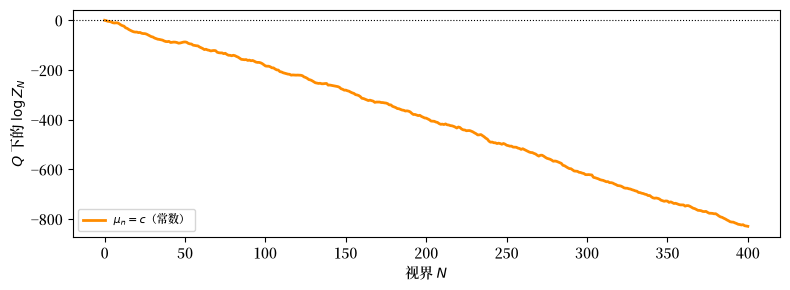

In [8]:
label, μ_seq = cases[0]
x = rng.standard_normal(N_plot)
log_Z_inc = μ_seq[:N_plot] * x - μ_seq[:N_plot]**2 / 2
log_Z = np.concatenate([[0], np.cumsum(log_Z_inc)])

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(np.arange(N_plot + 1), log_Z,
        color='darkorange', lw=2, label=label)
ax.axhline(0, color='black', lw=0.8, ls=':')
ax.set_xlabel('视界 $N$')
ax.set_ylabel(r'$Q$ 下的 $\log Z_N$')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

$\mu_n = c/\sqrt{n}$ 的情形显示出相同的定性图景：尽管漂移消失，但消失得太慢。

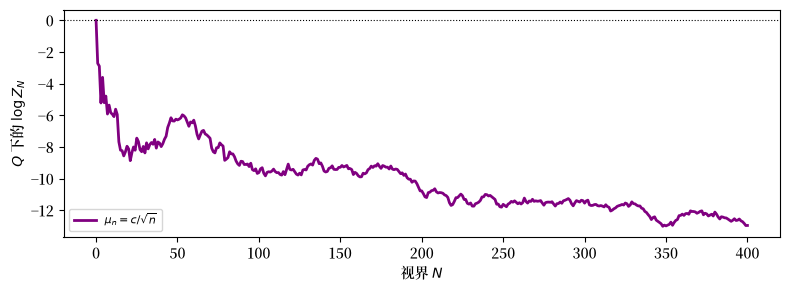

In [9]:
label, μ_seq = cases[1]
x = rng.standard_normal(N_plot)
log_Z_inc = μ_seq[:N_plot] * x - μ_seq[:N_plot]**2 / 2
log_Z = np.concatenate([[0], np.cumsum(log_Z_inc)])

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(np.arange(N_plot + 1), log_Z,
        color='purple', lw=2, label=label)
ax.axhline(0, color='black', lw=0.8, ls=':')
ax.set_xlabel('视界 $N$')
ax.set_ylabel(r'$Q$ 下的 $\log Z_N$')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

只有在 $\mu_n = c/n$ 时 $\sum (1-\rho_n) < \infty$ 才成立，因此似然比保持非退化且 $P \sim Q$。

布莱克韦尔-杜宾斯仅在此情形下适用。

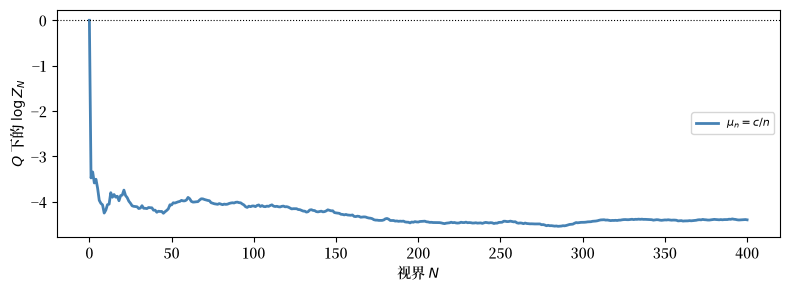

In [10]:
label, μ_seq = cases[2]
x = rng.standard_normal(N_plot)
log_Z_inc = μ_seq[:N_plot] * x - μ_seq[:N_plot]**2 / 2
log_Z = np.concatenate([[0], np.cumsum(log_Z_inc)])

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(np.arange(N_plot + 1), log_Z,
        color='steelblue', lw=2, label=label)
ax.axhline(0, color='black', lw=0.8, ls=':')
ax.set_xlabel('视界 $N$')
ax.set_ylabel(r'$Q$ 下的 $\log Z_N$')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 推广到连续时间

同样的逻辑推广到连续时间。

### 吉尔萨诺夫定理与似然比过程

在典范维纳空间上，$Q$ 为维纳测度（标准
布朗运动 $W$），假设主体 $P$ 相信该过程有一个
额外漂移 $\theta = \{\theta_s\}_{s \geq 0}$：

$$
W_t = \widetilde{W}_t + \int_0^t \theta_s\, ds,
$$

其中 $\widetilde{W}$ 是一个 $P$-布朗运动。

吉尔萨诺夫-卡梅隆-马丁定理 {cite:p}`girsanov1960` 将
似然比过程给出为随机指数

$$
Z_t
= \exp\!\left(\int_0^t \theta_s\, dW_s - \frac{1}{2}\int_0^t \theta_s^2\, ds\right).
$$

$Z_t$ 始终是一个非负的 $Q$-局部鞅；它是一个真鞅
当且仅当对所有 $t$，$\mathbb{E}_Q[Z_t] = 1$。

诺维科夫条件 {cite:p}`novikov1972`，
对所有 $T$，$\mathbb{E}_Q\!\left[\exp\!\left(\tfrac{1}{2}\int_0^T \theta_s^2\,ds\right)\right] < \infty$，
是充分的。

### 无穷远处的二分法

$[0,+\infty)$ 上的一个关键微妙之处是局部绝对连续性*不*蕴含 $\mathscr{F}_\infty$ 上的全局绝对连续性。

```{prf:remark} 无限视界的微妙之处
:label: dichotomy_at_infinity

假设 $Z_t$ 对每个有限视界都是一个真 $Q$-鞅，并令 $Z_t \to Z_\infty$ $Q$-a.s.

如果 $\{Z_t\}$ 在 $[0,\infty)$ 上一致可积，那么在 $\mathscr{F}_\infty$ 上 $P \ll Q$，且 $dP/dQ = Z_\infty$。

对于布莱克韦尔-杜宾斯结论，我们需要在 $\mathscr{F}_\infty$ 上 $Q \ll P$（反方向）。

在许多标准设定中，包括满足下面能量条件的确定性漂移，这些测度实际上在 $\mathscr{F}_\infty$ 上是*等价的*（$P \sim Q$），因此两个方向都成立。

如果一致可积性失败，那么 $\mathscr{F}_\infty$ 上的全局绝对连续性可能失败。

在许多标准例子中，包括一个非零常数漂移，这些测度实际上在 $\mathscr{F}_\infty$ 上是奇异的。
```

确定性漂移例子中的一个方便的充分条件是**能量条件**

$$
\int_0^\infty \theta_s^2\,ds < \infty \quad Q\text{-a.s.}
$$

非形式地说，这表示在无限视界上区分两个测度的信息总量是有限的。

在能量条件下，$\mathscr{F}_\infty$ 上 $P \sim Q$，因此布莱克韦尔-杜宾斯适用，融合在两个测度下都成立。

当 $\theta$ 是非零常数时，该条件失败，这些测度在 $\mathscr{F}_\infty$ 上奇异，融合不会发生。

一旦在 $\mathscr{F}_\infty$ 上建立了 $Q \ll P$，连续时间布莱克韦尔-杜宾斯结果的证明
就与离散时间证明完全相同。

$\{d_t, \mathscr{F}_t\}$ 是 $[0,1]$ 中的非负 $Q$-上鞅，因此 $d_t \to d_\infty$ $Q$-a.s.

$L^1$ 界
$\mathbb{E}_Q[d_t] = \tfrac{1}{2}\mathbb{E}_P[|Z_t - Z_\infty|] \to 0$
迫使 $d_\infty = 0$。


## 应用

### 贝叶斯学习

最直接的应用是贝叶斯推断。

假设数据 $(x_1, x_2, \ldots)$ 从真实测度 $Q^*$ 抽取。

一个主体在族 $\{Q_\theta : \theta \in \Theta\}$ 上持有先验 $\pi$，诱导出边缘 $P = \int Q_\theta\,\pi(d\theta)$。

如果 $Q^* \ll P$（即主体的边缘模型支配真值），那么布莱克韦尔-杜宾斯给出

$$
\bigl\|P(\,\cdot\,|\,x_1,\ldots,x_n) - Q^*(\,\cdot\,|\,x_1,\ldots,x_n)\bigr\|_{\mathrm{TV}}
\to 0 \quad Q^*\text{-a.s.}
$$

这是贝叶斯一致性的一种强形式：主体的预测在真实测度下与真值融合。

对真实参数邻域赋予正质量的先验通常保证对每个有限视界 $n$ 的*局部*绝对连续性 $Q^*_n \ll P_n$，但不保证布莱克韦尔-杜宾斯所要求的 $\mathscr{F}_\infty$ 上的全局条件 $Q^* \ll P$。

例如，在具有非原子先验 $\pi$ 的贝塔-伯努利模型中，混合 $P = \int \mathrm{Bernoulli}(p)^{\infty}\,\pi(dp)$ 对每个 $n$ 满足 $Q^*_n \ll P_n$，但全局上 $Q^* \not\ll P$，因为集合 $\{\lim k_n/n = p^*\}$ 的 $Q^*$-测度为一，但 $P$-测度为零（不同的伯努利乘积测度相互奇异）。

在额外结构下，全局绝对连续性确实成立，例如当参数空间有限或模型足够正则以允许杜布一致性论证时。

{cite:t}`DiaconisFreedman1986` 研究贝叶斯估计的一致性，并在其他结果中表明，局部与全局绝对连续性之间的相互作用在确保后验收敛中起着核心作用。

当 $P \perp Q^*$ 时，存在在 $Q^*$ 下概率为一但在 $P$ 下概率为零的事件，因此主体的信念仍然从根本上被错误设定。

### 理性预期与异质先验

在宏观经济学中，理性预期模型通常施加共同先验。

布莱克韦尔-杜宾斯为较弱的初始一致性提供了动态论证。

如果两个主体从等价先验出发并观察相同的历史，他们的条件预测最终在每个事件上达成一致。

{cite:t}`aumann1976` 的一致性定理强化了这一点：具有
共同先验的主体不能对后验概率"同意不一致"。

布莱克韦尔-杜宾斯补充了奥曼，表明等价先验足以实现最终一致。

### 遍历马尔可夫链

对于具有转移核 $\Pi$ 和两个初始
分布 $\mu$ 和 $\nu$ 的马尔可夫链，$n$-步分布为 $\mu\Pi^n$
和 $\nu\Pi^n$。

如果 $\Pi$ 是遍历的，具有唯一平稳分布
$\pi$，两者都收敛到 $\pi$，因此

$$
\|\mu\Pi^n - \nu\Pi^n\|_{\mathrm{TV}}
\leq \|\mu\Pi^n - \pi\|_{\mathrm{TV}} + \|\nu\Pi^n - \pi\|_{\mathrm{TV}}
\to 0.
$$

这是融合的一种特殊形式，它*不*要求绝对连续性，因为遍历性已经迫使两个分布趋于相同的极限。

布莱克韦尔-杜宾斯是非遍历或非马尔可夫环境的正确类比，在这些环境中不必存在单一的不变分布。


## 融合的速率

布莱克韦尔-杜宾斯是定性的。

它告诉我们 $d_n \to 0$，但没有告诉我们速度有多快。

界

$$
\mathbb{E}_Q[d_n] = \tfrac{1}{2}\,\mathbb{E}_P[|Z_n - Z_\infty|]
$$

表明融合的速率由似然比鞅的 $L^1(P)$ 收敛速率控制。

在正则参数例子中，人们常常看到 $n^{-1/2}$ 型的行为。

下图在贝塔-伯努利模型中检验了这个启发式。

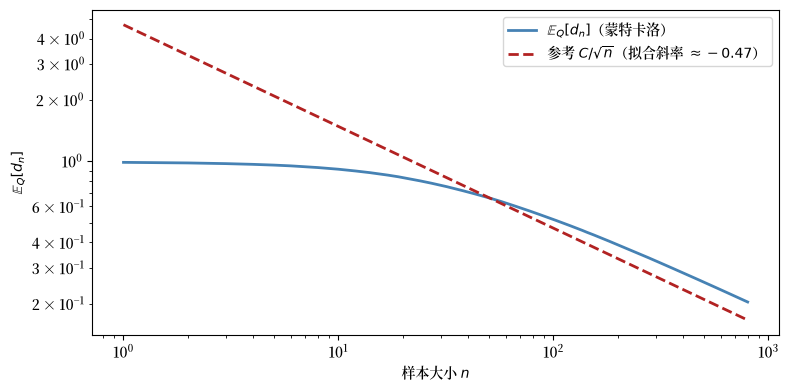

拟合的对数-对数斜率: -0.469  (预测: -0.50)


In [11]:
N_paths_rate = 200
n_steps_rate = 800

tv_rate = np.empty((N_paths_rate, n_steps_rate + 1))
for i in range(N_paths_rate):
    s = run_simulation(p_true, a1, b1, a2, b2, n_steps_rate, seed=100 + i)
    tv_rate[i] = s['tv_beta']

ns_rate  = np.arange(1, n_steps_rate + 1)
mean_tv  = tv_rate[:, 1:].mean(axis=0)    # 平均 d_n, n = 1, ..., n_steps_rate

# 使用样本的后半部分拟合参考线 d_n ~ C / sqrt(n)
fit_start = 200
log_ns  = np.log(ns_rate[fit_start:])
log_tv  = np.log(mean_tv[fit_start:] + 1e-12)
coeffs  = np.polyfit(log_ns, log_tv, 1)
slope   = coeffs[0]

# 参考曲线 C/sqrt(n)
C_ref   = np.exp(coeffs[1])
ref_curve = C_ref / np.sqrt(ns_rate)

fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(ns_rate, mean_tv,  color='steelblue', lw=2,
          label=r'$\mathbb{E}_Q[d_n]$（蒙特卡洛）')
ax.loglog(ns_rate, ref_curve, color='firebrick', lw=2, ls='--',
          label=(rf'参考 $C/\sqrt{{n}}$'
                 rf'（拟合斜率 $\approx {slope:.2f}$）'))
ax.set_xlabel('样本大小 $n$')
ax.set_ylabel(r'$\mathbb{E}_Q[d_n]$')
ax.legend()
plt.tight_layout()
plt.show()

print(f"拟合的对数-对数斜率: {slope:.3f}  (预测: -0.50)")

拟合样本的后半部分给出接近 $-0.5$ 的斜率。

这与本模拟中的 $n^{-1/2}$ 标度一致。


## 总结与推广

布莱克韦尔-杜宾斯定理背后的逻辑流程是：

$$
Q \ll P
\;\Longrightarrow\;
Z = \frac{dQ}{dP} \in L^1(P)
\;\Longrightarrow\;
Z_n = \mathbb{E}_P[Z \,|\, \mathscr{F}_n]
\xrightarrow{L^1(P)}
Z_\infty
\;\Longrightarrow\;
d_n \xrightarrow{Q\text{-a.s.}} 0.
$$

要点：

1. 单边绝对连续性 $Q \ll P$ 给出 $Q$-几乎必然的融合。对于在*两个*测度下的融合，需要相互绝对连续性 $P \sim Q$。

2. 似然比鞅 $Z_n = \mathbb{E}_P[Z|\mathscr{F}_n]$ 及其 $L^1(P)$ 收敛驱动了这个结果。

3. 更多的数据只能（在期望上）降低区分两个假设的难度。

4. 对于无限乘积测度，角谷定理给出一个尖锐的等价性与奇异性二分法：要么 $P \sim Q$（当 $\sum_n (1 - \rho_n) < \infty$ 时），要么 $P \perp Q$（当该和发散时），不存在中间情形。

5. 当 $P \sim Q$ 时，布莱克韦尔-杜宾斯适用，融合在两个测度下都发生；当 $P \perp Q$ 时，分歧永远持续。

### 经济学中的应用

一些有影响力的应用和推广是：

- {cite}`KalaiLehrer1993Nash`：当先验关于真值绝对连续时，重复博弈学习驱动策略趋向纳什行为。
- {cite}`KalaiLehrer1993Subjective`：在相同条件下，主观均衡和客观均衡渐近地重合。
- {cite}`KalaiLehrer1994Merging`：为完全全变差收敛过强的环境引入了弱和强融合概念。
- {cite}`KalaiLehrerSmorodinsky1999`：将融合与校准预测联系起来。
- {cite}`JacksonKalaiSmorodinsky1999`：将德菲内蒂式的表示与贝叶斯学习和后验收敛联系起来。
- {cite}`JacksonKalai1999`：社会学习削弱了依赖于跨群体持续分歧的声誉效应。
- {cite}`Sandroni1998Nash`：表明近似绝对连续性条件足以在重复博弈中实现纳什型收敛。
- {cite}`MillerSanchirico1999`：给出了一个替代证明，并从相互有利的赌注角度对持续分歧作出了经济学解释。
- {cite}`LehrerSmorodinsky1996Compatible`：研究超越布莱克韦尔-杜宾斯绝对连续性的更广泛的兼容性概念。
- {cite}`LehrerSmorodinsky1996Learning`：综述重复策略环境中的融合与学习。
- {cite}`Nyarko1994`：将绝对连续性下的贝叶斯学习与趋向相关均衡的收敛联系起来。
- {cite}`PomattoAlNajjarSandroni2014`：将定理推广到有限可加概率，并将融合与检验可操纵性联系起来。
- {cite}`AcemogluChernozhukovYildiz2016`：表明当主体对信号结构本身不确定时分歧如何持续。

### 一个来自概率论的配套结果

{cite}`DiaconisFreedman1986` 研究贝叶斯估计的一致性，证明了涉及后验收敛的等价性，并提供了突出先验作用的反例。

他们的工作与布莱克韦尔-杜宾斯处于相同的思想传统中，在经济学学习文献中通常与融合定理一起被引用。